In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Мартингальный подход в сравнении с вальдовским


## Вспомогательные функции


In [2]:
def prob_wald(A, B):

    denom = np.exp( A + B ) - 1

    alpha = ( np.exp( B ) - 1 ) / denom
    beta = ( np.exp( A ) - 1 ) / denom
    
    return alpha, beta

In [3]:
def border_wald(alpha, beta):

    A = np.log((1 - beta) / alpha)
    B = np.log((1 - alpha) / beta)
    
    return A, B

In [4]:
def prob_mart(A, B, mu_0, mu_1):

    denom0 = np.exp(- 2 * mu_0 * A) - np.exp(2 * mu_0 * B)
    denom1 = np.exp(- 2 * mu_1 * A) - np.exp(2 * mu_1 * B)
    
    alpha = (1 - np.exp(2 * mu_0 * B)) / denom0
    beta = (np.exp(- 2 * mu_1 * A) - 1) / denom1
    
    return alpha, beta

In [5]:
def border_mart(alpha, beta, mu_0, mu_1, init_A=1.0, init_B=1.0):
    def equations(vars):
        A, B = vars
        
        denom0 = np.exp(- 2 * mu_0 * A) - np.exp(2 * mu_0 * B)
        denom1 = np.exp(- 2 * mu_1 * A) - np.exp(2 * mu_1 * B)
        
        # Система уравнений (f(A, B) - target = 0)
        eq1 = (1 - np.exp(2 * mu_0 * B)) / denom0 - alpha
        eq2 = (np.exp(- 2 * mu_1 * A) - 1) / denom1 - beta
        
        return [eq1, eq2]

    # Решаем систему с ограничениями на строго положительные A и B
    # Нижняя граница установлена как 1e-10 вместо 0, чтобы избежать деления на ноль при A=0, B=0
    res = least_squares(
        equations, 
        x0=[init_A, init_B], 
        bounds=([1e-10, 1e-10], [np.inf, np.inf])
    )
    
    if res.success:
        return res.x[0], res.x[1]
    else:
        raise RuntimeError(f"Решение не найдено: {res.message}")

## Пример работы 1

\begin{align*}

    X_i &\sim N(\theta , \sigma) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}
 


In [80]:
theta0 = -1
theta1 = 1
sigma = 2

alpha = 0.05
beta = 0.05

In [81]:
mu = ( (theta1 - theta0) ** 2 ) / ( 2 * (sigma ** 2) ) 

sigma0 = 2 * mu  # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе

a_0 = - mu # среднее логарифма отношения правдоподобий при гипотезе
a_1 = mu # среднее логарифма отношения правдоподобий при альтернативе

In [82]:
A_mart , B_mart = border_mart(alpha, beta, a_0 / sigma0, a_1 / sigma0)
A_wald , B_wald  = border_wald(alpha, beta)

# границы Вальда и мартингальные совпадают при нормальных шагах: 

print(A_mart , B_mart)
print(A_wald, B_wald)

2.9444388737831853 2.9444388737831853
2.9444389791664403 2.9444389791664403


## Пример работы 2

\begin{align*}

    X_i &\sim Bern (\theta) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}

In [84]:
N = 50 # количество наблюдений

theta0 = 1/4
theta1 = 2/3

theta_set = [1/4, 2/3, 1/2]

alpha = 0.01
beta = 0.01

In [85]:
N_nodes = np.arange(N + 1)

a = np.log(theta1 / theta0)
b = np.log((1 - theta1) / (1 - theta0))
k = a - b

a_0 = theta0 * k + b # среднее логарифма отношения правдоподобий при гипотезе
a_1 = theta1 * k + b # среднее логарифма отношения правдоподобий при альтернативе

sigma0 = ( k ** 2 ) * theta0 * (1 - theta0) # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе

In [86]:
print(a_0, a_1, sigma0)

-0.3629903489093149 0.38357609660237457 0.6019503741690753


In [87]:
A_mart , B_mart = border_mart(alpha, beta, a_0 / sigma0, a_1 / sigma0)
A_wald , B_wald  = border_wald(alpha, beta)

print(f'Мартингальная граница А: {A_mart:.3f}')
print(f'Мартингальная граница В: {B_mart:.3f}\n')

print(f'Вальдоваская граница А: {A_wald:.3f}')
print(f'Вальдоваская граница В: {B_wald:.3f}')

Мартингальная граница А: 3.808
Мартингальная граница В: 3.607

Вальдоваская граница А: 4.595
Вальдоваская граница В: 4.595


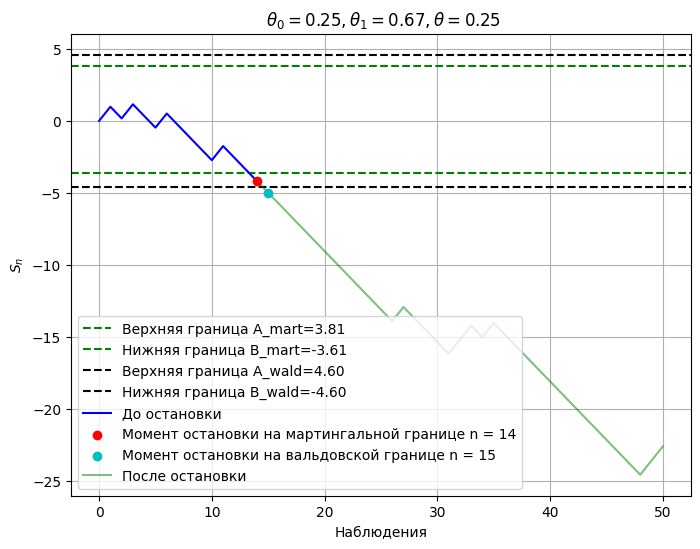

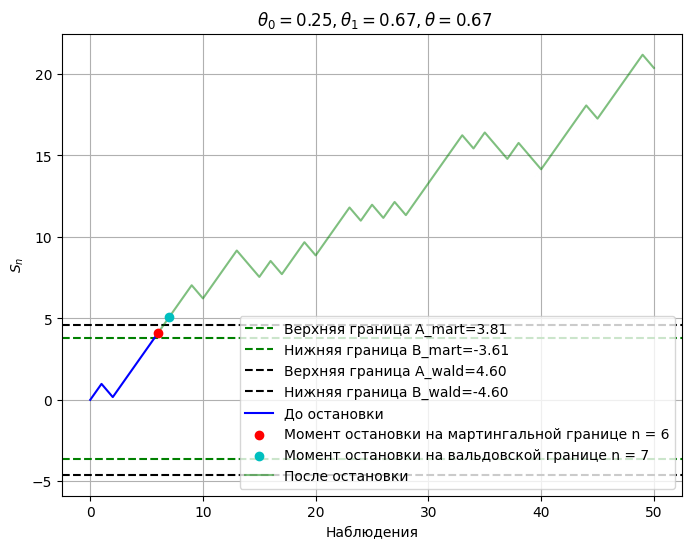

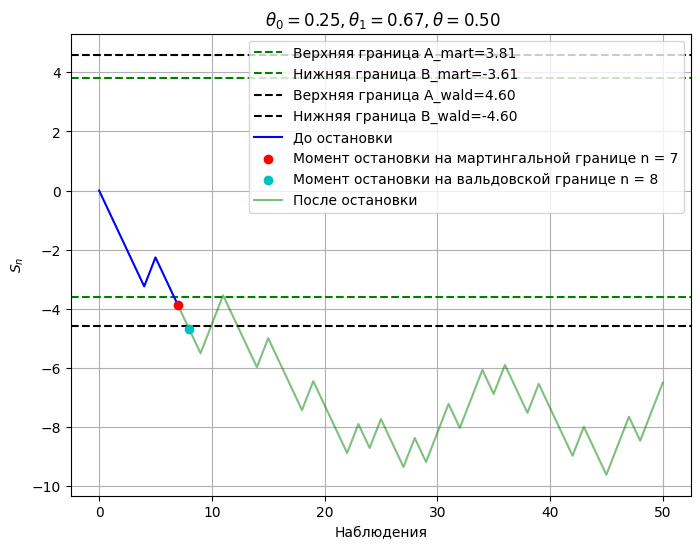

In [ ]:
for theta in theta_set:
    
    x = sps.bernoulli.rvs(p=theta, size=N)

    step_X = x * k + b

    X = np.zeros(N + 1)

    X[1:] = np.cumsum(step_X)

    condition1_mart = (X >= A_mart)
    condition2_mart = (X <= - B_mart)
    where_crossed_mart = np.where(condition1_mart | condition2_mart)[0]

    if where_crossed_mart.size > 0:
        idx_mart = where_crossed_mart[0]
    else:
        idx_mart = N 

    condition1_wald = (X >= A_wald)
    condition2_wald = (X <= - B_wald)

    where_crossed_wald = np.where(condition1_wald | condition2_wald)[0]

    if where_crossed_wald.size > 0:
        idx_wald = where_crossed_wald[0]
    else:
        idx_wald = N 

    plt.figure(figsize=(8, 6))

    plt.axhline(y=A_mart, color='g', linestyle='--', label=f'Верхняя граница A_mart={A_mart:.2f}')
    plt.axhline(y=-B_mart, color='g', linestyle='--', label=f'Нижняя граница -B_mart={-B_mart:.2f}')

    plt.axhline(y=A_wald, color='black', linestyle='--', label=f'Верхняя граница A_wald={A_wald:.2f}')
    plt.axhline(y=-B_wald, color='black', linestyle='--', label=f'Нижняя граница -B_wald={-B_wald:.2f}')

    plt.plot(N_nodes[:idx_mart+1], X[:idx_mart+1], color='blue', label='До остановки (март.)')
    
    if idx_mart < N:
        plt.scatter(N_nodes[idx_mart], X[idx_mart], label=f'Остановка март. n = {idx_mart}', color='red', zorder=5)
        plt.plot(N_nodes[idx_mart:], X[idx_mart:], color='green', alpha=0.5, label='После остановки')
        
    if idx_wald < N:
        plt.scatter(N_nodes[idx_wald], X[idx_wald], label=f'Остановка Вальд n = {idx_wald}', color='c', zorder=5)

    plt.title(fr'$\theta_0 = {theta0:.2f}, \theta_1 = {theta1:.2f}, \theta = {theta:.2f}$')
    plt.xlabel('Наблюдения')
    plt.ylabel(r'$Z_n$') 
    plt.legend()
    plt.grid(True)
    plt.show()

## Пример работы 3

\begin{align*}

    X_i &\sim Exp (\theta) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}

In [100]:
N = 50 # количество наблюдений

theta0 = 1
theta1 = 2

theta_set = [1, 2, 1.5]

alpha = 0.01
beta = 0.01

In [101]:
# экспоненциальное распределение
N_nodes = np.arange(N + 1)

b = np.log(theta1 / theta0)
k = theta0 - theta1

a_0 = k / theta0 + b # среднее логарифма отношения правдоподобий при гипотезе
a_1 = k / theta1 + b # среднее логарифма отношения правдоподобий при альтернативе

sigma0 = ( k ** 2 ) / ( theta0 ** 2 ) # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе

In [102]:
print(a_0, a_1, sigma0)

-0.3068528194400547 0.1931471805599453 1.0


In [103]:
A_mart , B_mart = border_mart(alpha, beta, a_0 / sigma0, a_1 / sigma0)
A_wald , B_wald  = border_wald(alpha, beta)

print(f'Мартингальная граница А: {A_mart:.3f}')
print(f'Мартингальная граница В: {B_mart:.3f}\n')

print(f'Вальдоваская граница А: {A_wald:.3f}')
print(f'Вальдоваская граница В: {B_wald:.3f}')

Мартингальная граница А: 7.503
Мартингальная граница В: 11.776

Вальдоваская граница А: 4.595
Вальдоваская граница В: 4.595


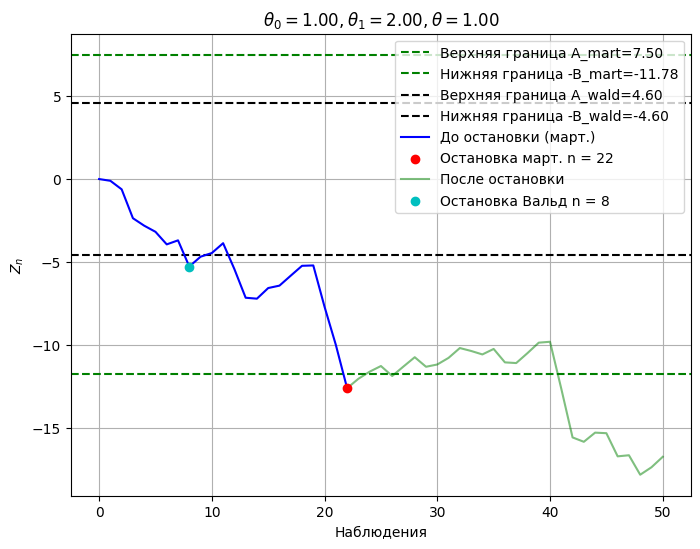

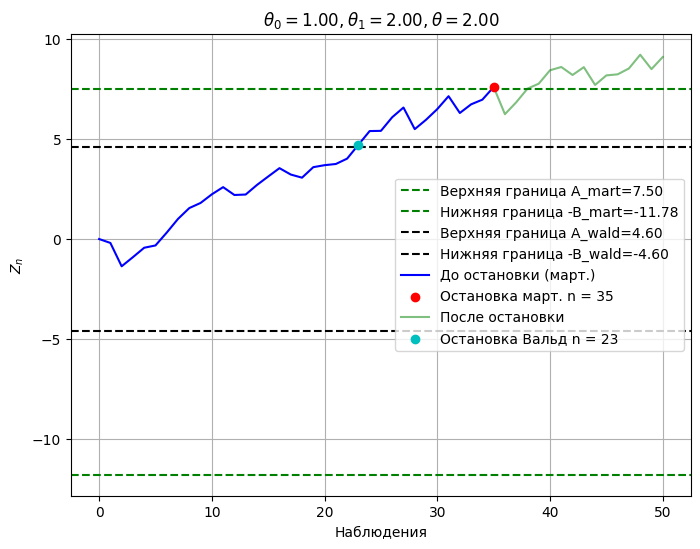

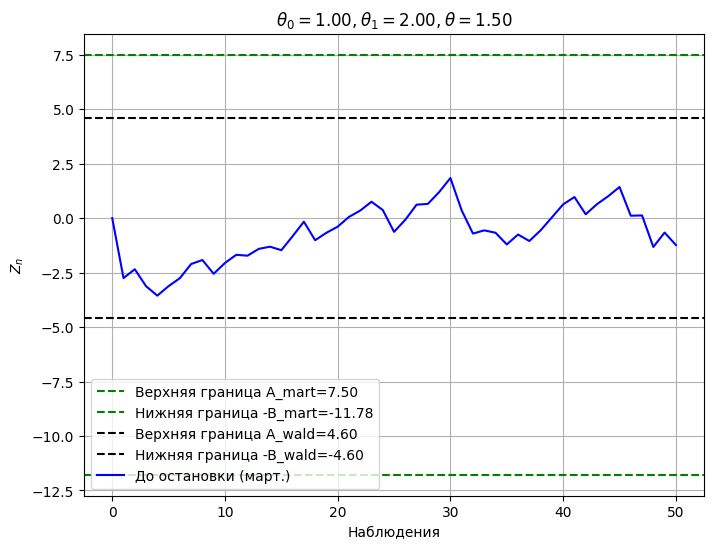

In [106]:
for theta in theta_set:
    
    # Исправлена генерация: scale = 1/theta
    x = sps.expon.rvs(scale=1/theta, size=N)

    step_X = x * k + b

    X = np.zeros(N + 1)
    X[1:] = np.cumsum(step_X)

    condition1_mart = (X >= A_mart)
    condition2_mart = (X <= -B_mart)
    where_crossed_mart = np.where(condition1_mart | condition2_mart)[0]

    if where_crossed_mart.size > 0:
        idx_mart = where_crossed_mart[0]
    else:
        idx_mart = N 
    
    condition1_wald = (X >= A_wald)
    condition2_wald = (X <= -B_wald)
    where_crossed_wald = np.where(condition1_wald | condition2_wald)[0]

    if where_crossed_wald.size > 0:
        idx_wald = where_crossed_wald[0]
    else:
        idx_wald = N 

    plt.figure(figsize=(8, 6))

    plt.axhline(y=A_mart, color='g', linestyle='--', label=f'Верхняя граница A_mart={A_mart:.2f}')
    plt.axhline(y=-B_mart, color='g', linestyle='--', label=f'Нижняя граница -B_mart={-B_mart:.2f}')

    plt.axhline(y=A_wald, color='black', linestyle='--', label=f'Верхняя граница A_wald={A_wald:.2f}')
    plt.axhline(y=-B_wald, color='black', linestyle='--', label=f'Нижняя граница -B_wald={-B_wald:.2f}')

    plt.plot(N_nodes[:idx_mart+1], X[:idx_mart+1], color='blue', label='До остановки (март.)')
    
    if idx_mart < N:
        plt.scatter(N_nodes[idx_mart], X[idx_mart], label=f'Остановка март. n = {idx_mart}', color='red', zorder=5)
        plt.plot(N_nodes[idx_mart:], X[idx_mart:], color='green', alpha=0.5, label='После остановки')
        
    if idx_wald < N:
        plt.scatter(N_nodes[idx_wald], X[idx_wald], label=f'Остановка Вальд n = {idx_wald}', color='c', zorder=5)

    plt.title(fr'$\theta_0 = {theta0:.2f}, \theta_1 = {theta1:.2f}, \theta = {theta:.2f}$')
    plt.xlabel('Наблюдения')
    plt.ylabel(r'$Z_n$') 
    plt.legend()
    plt.grid(True)
    plt.show()

## Эмпирические вероятности ошибок 1 и 2 рода

In [ ]:
N = 50 # количество наблюдений

theta0 = 1/4
theta1 = 2/3

theta_set = [1/4, 2/3, 1/2]

alpha = 0.01
beta = 0.01

In [60]:
a = np.log(theta1 / theta0)
b = np.log((1 - theta1) / (1 - theta0))
k = a - b

a_0 = theta0 * k + b # среднее логарифма отношения правдоподобий при гипотезе
a_1 = theta1 * k + b # среднее логарифма отношения правдоподобий при альтернативе

sigma0 = ( k ** 2 ) * theta0 * (1 - theta0) # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе

In [61]:
A_mart , B_mart = border_mart(alpha, beta, a_0 / sigma0, a_1 / sigma0)
A_wald , B_wald  = border_wald(alpha, beta)

In [67]:
dist_functions = {
        'normal': sps.norm.cdf,
        'uniform': sps.uniform.cdf,
        'exponential': sps.expon.cdf,
        'poisson': sps.poisson.cdf,
        'binomial': sps.binom.cdf,
        'bernoulli': sps.bernoulli.rvs,
        'gamma': sps.gamma.cdf
    }

In [72]:
def step_x (theta, theta0, theta1, distrib = 'bernoulli'):

    if distrib == 'bernoulli':

        a = np.log(theta1 / theta0)
        b = np.log((1 - theta1) / (1 - theta0))
        k = a - b

        x = dist_functions[distrib](p=theta, size=N)
        step_X = x * k + b
    else:
        step_X = np.zeros(N)
    # и тд/ надо доделать
    return step_X

In [76]:
def calculate_errors(A, B, num_trials, distrib = 'bernoulli'):

    type1_errors = 0

    type2_errors = 0
    type2_errors = 0


    for _ in range(num_trials):

        for true_theta in theta_set:

            X = np.zeros(N + 1)
            
            step_X = step_x (true_theta, theta0, theta1, distrib)
            X[1:] = np.cumsum(step_X)

            condition1 = (X >= A)
            condition2 = (X <= - B)
            where_crossed = np.where(condition1 | condition2)[0]

            if where_crossed.size > 0:
                idx = where_crossed[0]
            else:
                idx = N 

            if true_theta == theta0:
                if X[idx] >= A:
                    type1_errors += 1
            elif true_theta == theta1:
                if X[idx] <= -B:
                    type2_errors += 1

    emp_alpha = type1_errors / num_trials
    emp_beta = type2_errors / num_trials

    return emp_alpha, emp_beta

In [77]:
num = 10000
distrib = 'bernoulli'

emp_alpha_wald, emp_beta_wald = calculate_errors(A_wald, B_wald, num, distrib)
emp_alpha_mart, emp_beta_mart = calculate_errors(A_mart, B_mart, num)

print(f"Распределение: {distrib}")
print(f"Заданные ошибки первого и второго рода: {alpha,beta}\n")

print(f"Эмпирические ошибки первого и второго рода при вальдовских границах: {emp_alpha_wald, emp_beta_wald}\n")

print(f"Эмпирические ошибки первого и второго рода при мартингальных границах: {emp_alpha_mart, emp_beta_mart}")


Распределение: bernoulli
Заданные ошибки первого и второго рода: (0.01, 0.01)

Эмпирические ошибки первого и второго рода при вальдовских границах: (0.0066, 0.0071)

Эмпирические ошибки первого и второго рода при мартингальных границах: (0.0148, 0.0174)
